# **Experiment 2**

In [1]:
# Do not modify this code
!pip install -q utstd imbalanced-learn

from utstd.ipyrenders import *

In [2]:
# Do not modify this code
import warnings
warnings.simplefilter(action='ignore')

In [3]:
import pandas as pd

pd.__version__

'2.2.2'

---
## Student Information

In [4]:
# <Student to fill this section>
student_name = "Ratnadeep Patra"
student_id = "26294153"

In [5]:
# Do not modify this code
print_tile(size="h1", key='student_name', value=student_name)

In [6]:
# Do not modify this code
print_tile(size="h1", key='student_id', value=student_id)

---
## 0. Python Packages

In [7]:
import adv_ml_at2 as at2
import cloudpickle
import matplotlib.pyplot as plt
import numpy as np
import optuna
import seaborn as sns

from adv_ml_at2.modeling.custom_models import make_smote_classifier
from mlweave.workflow.workflow import MLWorkflow
from mlweave.workflow.decorators.step import inference_step
from optuna.integration import OptunaSearchCV
from sklearn.base import clone
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, f1_score, make_scorer, recall_score
import adv_ml_at2.modeling.custom_models as custom_models_module
from itertools import combinations

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("max_colwidth", None)

optuna.logging.set_verbosity(optuna.logging.WARNING)

---
## A. Project Description

In [8]:
forecast_horizons_days = 7

business_use_case_description = f"""
The business use case is {forecast_horizons_days}-day-ahead weather hazard forecasting for Sydney, with particular emphasis on identifying potentially dangerous conditions before they occur. The Weather Hazard Category combines 
precipitation, wind gusts, cloud cover, snowfall and temperature into four interpretable levels: Low Risk, Moderate Risk, High Risk and Extreme Risk. Historical weather observations are used to predict the expected hazard category 
exactly {forecast_horizons_days} days ahead so organisations can identify periods that may require additional preparation without having to interpret several weather variables independently. This type of early indication can support 
transport planning, outdoor events, workforce scheduling, infrastructure preparation and other activities that may be affected by hazardous weather. Particular attention is given to High Risk and Extreme Risk conditions because 
these less common events may require more preparation and can have greater operational consequences if they are not identified early. The model is intended to support early planning and monitoring rather than act as an automatic 
warning or cancellation system.
"""

In [9]:
# Do not modify this code
print_tile(size="h3", key='business_use_case_description', value=business_use_case_description)

In [10]:
business_objectives = """
The main business objective is to provide organisations with enough advance warning to recognise periods where weather conditions may create greater operational risk. A useful prediction should allow stakeholders to distinguish 
between normal conditions that require little additional preparation and more hazardous conditions where contingency planning, additional monitoring or changes to normal operations may be appropriate. The consequences of different 
prediction errors are not equal. If a genuinely High Risk or Extreme Risk day is predicted as Low or Moderate Risk, organisations may underestimate the expected conditions and fail to prepare sufficiently. This can be more costly 
than incorrectly identifying a lower-risk day as more hazardous, where the likely consequence is additional monitoring or precautionary preparation that may later prove unnecessary. For this reason, particular importance is placed 
on avoiding missed High Risk and Extreme Risk conditions. At the same time, the model should not repeatedly generate unnecessarily severe predictions, as frequent false alarms could lead to avoidable operational costs and reduce 
confidence in the service. The desired outcome is therefore a useful balance where hazardous conditions are identified consistently enough to support early preparation while the predictions remain practical for routine planning.
"""

In [11]:
# Do not modify this code
print_tile(size="h3", key='business_objectives', value=business_objectives)

In [12]:
stakeholders_expectations_explanations = f"""
Stakeholders using the service would expect a clear and understandable indication of weather risk {forecast_horizons_days} days in advance so that they have time to review upcoming operations and prepare where necessary. Rather 
than requiring users to interpret individual forecasts for rainfall, wind, cloud cover, snowfall and temperature, the Weather Hazard Category provides a single risk level that can be incorporated more easily into planning decisions. 
The service is also designed to make access to the prediction simple. Users only need to provide the date for which the forecast is required through a single API endpoint. The service internally retrieves the required weather 
information, prepares the relevant inputs and returns the predicted Weather Hazard Category. This removes the need for organisations using the service to separately collect, combine or process multiple weather variables and makes 
the forecasting capability easier to integrate into existing operational systems. For routine Low Risk or Moderate Risk predictions, stakeholders may continue normal planning while monitoring updated weather information. A High 
Risk prediction may justify closer monitoring, preparation of contingency plans or adjustments to weather-sensitive activities. An Extreme Risk prediction would warrant greater attention because failing to recognise such conditions 
early could have more serious operational consequences. Stakeholders would therefore expect the system to be particularly dependable when identifying the higher-risk categories. However, the prediction should still be treated as 
an early planning signal rather than a final operational decision. As the forecast date approaches, organisations can combine the model output with newer weather information and their own operational requirements before deciding 
whether any action is necessary.
"""

In [13]:
# Do not modify this code
print_tile(size="h3", key='stakeholders_expectations_explanations', value=stakeholders_expectations_explanations)

> Hypothesis: Applying SMOTE to the minority WHC classes will improve High and Extreme Risk recall compared with the baseline Elastic-Net Logistic Regression, and will be able to capture the missed high risk conditions without significant drop in precision.

---
## C. Data Understanding

### C.1 Load Raw Data

In [14]:
hourly_weather_df = pd.read_csv(at2.dataset.RAW_DATA_DIR / "sydney_weather_hourly.csv", parse_dates=["time"])
daily_weather_df = pd.read_csv(at2.dataset.RAW_DATA_DIR / "sydney_weather_daily.csv", parse_dates=["time"])
aggregation_rules = {
    "temperature_2m": ["mean", "max", "min", "median"],
    "relative_humidity_2m": ["mean", "max", "min", "median"],
    "wind_speed_10m": ["mean", "max"],
    "wind_speed_100m": ["mean", "max"],
    "wind_gusts_10m": ["mean", "max"],
    "cloud_cover": ["mean", "max"],
    "cloud_cover_low": ["mean", "max"],
    "cloud_cover_mid": ["mean", "max"],
    "cloud_cover_high": ["mean", "max"],
    "precipitation": ["sum", "max"],
    "snowfall": ["sum"],
    "pressure_msl": ["mean", "max", "min"],
    "dew_point_2m": ["mean", "max", "min"],
    "vapour_pressure_deficit": ["mean", "max"],
    "soil_moisture_0_to_7cm": ["mean"],
    "apparent_temperature": ["mean", "max", "min"],
    "shortwave_radiation": ["mean", "max"],
    "sunshine_duration": ["sum"]
}
daily_features_df = at2.dataset.build_daily_weather_dataset(hourly_weather_df=hourly_weather_df, daily_weather_df=daily_weather_df, aggregation_rules=aggregation_rules)
print("Daily weather shape:", daily_features_df.shape)

Daily weather shape: (9497, 44)


### C.2 Define Target variable

In [15]:
target_name = f"whc_target_{forecast_horizons_days}d"
target_label_name = f"whc_label_target_{forecast_horizons_days}d"

whc_class_definitions = pd.DataFrame([
    {"WHI condition": "WHI < 25", "WHC class": 0, "WHC label": "Low Risk"},
    {"WHI condition": "25 <= WHI < 50", "WHC class": 1, "WHC label": "Moderate Risk"},
    {"WHI condition": "50 <= WHI < 75", "WHC class": 2, "WHC label": "High Risk"},
    {"WHI condition": "WHI >= 75", "WHC class": 3, "WHC label": "Extreme Risk"}
])
display(whc_class_definitions)

,WHI condition,WHC class,WHC label
0,WHI < 25,0,Low Risk
1,25 <= WHI < 50,1,Moderate Risk
2,50 <= WHI < 75,2,High Risk
3,WHI >= 75,3,Extreme Risk


In [16]:
target_definition_explanations = f"""
The target definition is unchanged from Experiment 1. WHC is predicted {forecast_horizons_days} days ahead using the same four ordered risk categories and the same leakage-safe lagged predictor space.
"""

In [17]:
# Do not modify this code
print_tile(size="h3", key='target_definition_explanations', value=target_definition_explanations)

### C.3 Create Target variable

In [18]:
daily_whi_df = at2.features.aggregate_daily_whi(hourly_weather_df)
hazard_columns = ["rain_hazard", "wind_hazard", "cloud_hazard", "snow_hazard", "temperature_hazard", "whi", "whc", "whc_label"]

weather_df = daily_features_df.merge(daily_whi_df[["time"] + hazard_columns], on="time", how="inner", validate="one_to_one")
weather_df = at2.features.create_whc_forecast_targets(weather_df, horizon=forecast_horizons_days)
weather_df = at2.features.lag_feature_space(weather_df, target_columns=[target_name, target_label_name], lag_days=1)
weather_df = weather_df.dropna(subset=[target_name]).reset_index(drop=True)
weather_df[target_name] = weather_df[target_name].astype("int64")
print(f"Final supervised rows: {len(weather_df):,}")

Final supervised rows: 9,489


### C.4 Explore Target variable

In [19]:
target_distribution = weather_df[target_name].value_counts().sort_index().rename("count").to_frame()
target_distribution["label"] = target_distribution.index.map(at2.features.WHC_LABELS)
target_distribution["proportion"] = target_distribution["count"] / target_distribution["count"].sum()
display(target_distribution[["label", "count", "proportion"]].round(4))

,label,count,proportion
whc_target_7d,,,
0,Low Risk,5239,0.5521
1,Moderate Risk,3965,0.4179
2,High Risk,274,0.0289
3,Extreme Risk,11,0.0012


In [20]:
target_distribution_explanations = """
The severe class imbalance identified in Experiment 1 remains unchanged. Low and Moderate Risk observations dominate the data, while High Risk is uncommon and Extreme Risk is extremely rare. This imbalance is the specific
modelling issue tested in Experiment 2.
"""

In [21]:
# Do not modify this code
print_tile(size="h3", key='target_distribution_explanations', value=target_distribution_explanations)

### C.5 Explore Model Features

In [22]:
feature_1_insights = """
The EDA from Experiment 1 are reused unchanged. Experiment 2 therefore keeps the same representative feature rather than repeating the analysis.
"""

In [23]:
# Do not modify this code
print_tile(size="h3", key='feature_1_insights', value=feature_1_insights)

---
## D. Feature Selection

### D.1 Approach "Reuse Experiment 1 Selection"

In [24]:
feature_selection_1_insights = """
Experiment 2 reuses the final Experiment 1 feature selection unchanged. No feature is added or removed because this experiment isolates the effect of SMOTE.
"""

In [25]:
# Do not modify this code
print_tile(size="h3", key='feature_selection_1_insights', value=feature_selection_1_insights)

---
## E. Data Preparation

### E.1 Data Transformation "Reuse Experiment 1 Pipeline"

In [26]:
experiment_1_path = at2.config.MODELS_DIR / "weather_hazard" / "experiment_1" / "experiment_1.pkl"
with experiment_1_path.open("rb") as file:
    experiment_1_artifact = cloudpickle.load(file)
experiment_1_ml_workflow = experiment_1_artifact["ml_workflow"]
reference_preprocessing = getattr(experiment_1_ml_workflow, "preprocessing_", experiment_1_ml_workflow.preprocessing)
experiment_2_preprocessing = clone(reference_preprocessing)
print("Reused preprocessing steps:", [name for name, step in experiment_2_preprocessing.steps if step != "passthrough"])

Reused preprocessing steps: ['remove_non_model_labels', 'retain_selected_features', 'add_log1p_precipitation', 'add_annual_cycle_features', 'add_wind_direction_features', 'add_selected_whi_history', 'retain_complete_temporal_context', 'add_selected_interactions', 'temporal_train_validation_test_split', 'standardise_model_matrix']


In [27]:
data_transformation_1_explanations = """
The fitted Experiment 1 preprocessing pipeline is reused directly. This preserves its selected variables, log precipitation transformation, annual cycle, harmonics of wind direction, WHI exponentially weighted memory, temporal
context filtering, adding corss feature-interactions, chronological split and training-fitted standardisation.
"""

In [28]:
# Do not modify this code
print_tile(size="h3", key='data_transformation_1_explanations', value=data_transformation_1_explanations)

---
## F. Feature Engineering

### F.1 New Feature "Reuse Experiment 1 Engineered Features"

In [29]:
feature_engineering_seasonality_explanations = """
No new predictors are introduced in Experiment 2. The complete engineered feature space from Experiment 1 is retained so the experiment isolates the effect of changing minority-class representation during model training.
"""

In [30]:
# Do not modify this code
print_tile(size="h3", key='feature_engineering_seasonality_explanations', value=feature_engineering_seasonality_explanations)

---
## G. Data Preparation for Modeling

### G.1 Split Datasets

In [31]:
X_train, X_val, X_test = experiment_2_preprocessing.fit_transform(weather_df)
y_train, y_val, y_test = experiment_2_preprocessing.multiplex_y_
split_summary = pd.DataFrame({
    "rows": [len(X_train), len(X_val), len(X_test)],
    "proportion": np.array([len(X_train), len(X_val), len(X_test)]) / (len(X_train) + len(X_val) + len(X_test))
}, index=["train", "validation", "test"])
display(split_summary)
display(pd.concat({
    "train": y_train.value_counts(normalize=True).sort_index(),
    "validation": y_val.value_counts(normalize=True).sort_index(),
    "test": y_test.value_counts(normalize=True).sort_index()
}, axis=1).fillna(0).round(4))

,rows,proportion
train,8006,0.846300
validation,730,0.077167
test,724,0.076533


,train,validation,test
whc_target_7d,,,
0,0.5697,0.4836,0.4309
1,0.4039,0.4671,0.5180
2,0.0254,0.0466,0.0497
3,0.0010,0.0027,0.0014


In [32]:
data_splitting_explanations = """
The chronological train, validation and test partitions are produced by the reused Experiment 1 pipeline, keeping Experiment 2 directly comparable with the original classification baseline.
"""

In [33]:
# Do not modify this code
print_tile(size="h3", key='data_splitting_explanations', value=data_splitting_explanations)

### G.2 Data Transformation "Training-Fitted Standardisation"

In [34]:
data_transformation_3_explanations = """
The Experiment 1 preprocessing pipeline is reused unchanged. SMOTE is applied only after preprocessing and only during model fitting. Validation and test observations are never resampled, preserving a realistic evaluation of
performance on the original class distribution.
"""

In [35]:
# Do not modify this code
print_tile(size="h3", key='data_transformation_3_explanations', value=data_transformation_3_explanations)

---
## H. Save Datasets

In [36]:
data_final_path = at2.config.PROCESSED_DATA_DIR / "weather_hazard" / "experiment_2"
data_final_path.mkdir(parents=True, exist_ok=True)

In [37]:
# Do not modify this code
# Save training set
try:
  X_train.to_csv(f'{data_final_path}/X_train.csv', index=False)
  y_train.to_csv(f'{data_final_path}/y_train.csv', index=False)

  X_val.to_csv(f'{data_final_path}/X_val.csv', index=False)
  y_val.to_csv(f'{data_final_path}/y_val.csv', index=False)

  X_test.to_csv(f'{data_final_path}/X_test.csv', index=False)
  y_test.to_csv(f'{data_final_path}/y_test.csv', index=False)
except Exception as e:
  print(e)

---
## I. Selection of Performance Metrics

In [38]:
class_ids = sorted(at2.features.WHC_LABELS)
high_group_ids = class_ids[2:]
severity_weights = np.array([1.0, 1.0, 1.5, 1.5])

def severity_weighted_recall(y_true, y_pred):
    class_recalls = recall_score(y_true, y_pred, labels=class_ids, average=None, zero_division=0)
    return np.average(class_recalls, weights=severity_weights)

def macro_f1(y_true, y_pred):
    return f1_score(y_true, y_pred, labels=class_ids, average="macro", zero_division=0)

primary_metric = "severity_weighted_recall"
secondary_metric = "macro_f1"
classification_scorer = make_scorer(severity_weighted_recall)

In [39]:
performance_metrics_explanations = f"""
Experiment 2 retains {primary_metric} as the primary metric so comparison with Experiment 1 remains consistent. Recall is calculated independently for all four WHC classes and combined using severity weights of {severity_weights.tolist()} 
for Low, Moderate, High and Extreme Risk respectively, giving greater importance to detecting the more hazardous classes. Macro F1 is reported as a secondary metric because it balances precision and recall equally across the four 
classes. During model tuning, it provides a direct check that improvements in severe-risk recall are not achieved by generating excessive false positive predictions and substantially degrading precision.
"""

In [40]:
# Do not modify this code
print_tile(size="h3", key="performance_metrics_explanations", value=performance_metrics_explanations)

## J. Train Machine Learning Model

### J.1 Import Algorithm

In [41]:
algorithm_selection_explanations = """
Experiment 2 retains Elastic-Net Logistic Regression but introduces proportion-aware SMOTE to address the severe class imbalance identified in Experiment 1. SMOTE increases the number of minority training observations available 
to the classifier. A fixed SMOTE target such as balancing every class to the majority could be too aggressive, particularly for the very small Extreme Risk class. That's why a custom wrapper is used that uses a single sampling 
multiplier together with each class's representation relative to the majority. Very rare classes receive close to the full multiplier, while classes already close to the majority receive a smaller increase. All target counts 
remain capped at the majority count.
"""

In [42]:
# Do not modify this code
print_tile(size="h3", key='algorithm_selection_explanations', value=algorithm_selection_explanations)

### J.2 Set Hyperparameters

In [43]:
baseline_C = 0.009754
baseline_l1_ratio = 0.043866
baseline_intercept = False
baseline_k_neighbors = 3
sampling_multipliers = 1.0

In [44]:
hyperparameters_selection_explanations = f"""
The main hyperparameters in this experiment control both the SMOTE oversampling process and the Elastic-Net Logistic Regression classifier. sampling_multiplier controls how strongly minority classes are oversampled. A value of 
1 applies no oversampling, while larger values generate progressively more synthetic observations, with rarer classes receiving a larger proportional increase. k_neighbors controls how many nearby minority-class observations 
are considered when SMOTE generates each synthetic sample, thereby controlling how locally the new observations are constructed. For the Logistic Regression classifier, C controls the inverse strength of regularisation, where 
smaller values apply stronger coefficient shrinkage. l1_ratio controls the balance between L1 and L2 regularisation, with values closer to 1 placing greater emphasis on L1 sparsity and values closer to 0 placing greater emphasis 
on L2 shrinkage. fit_intercept allows a baseline class offset to be estimated in addition to the predictor coefficients.
"""

In [45]:
# Do not modify this code
print_tile(size="h3", key='hyperparameters_selection_explanations', value=hyperparameters_selection_explanations)

### J.3 Fit Model

In [46]:
def test_model(sampling_multiplier, C, l1_ratio, k_neighbors, intercept):
    model = make_smote_classifier(
        LogisticRegression(
            penalty="elasticnet",
            solver="saga",
            C=C,
            l1_ratio=l1_ratio,
            fit_intercept=intercept,
            max_iter=5000,
            random_state=42
        ),
        sampling_multiplier=sampling_multiplier, k_neighbors=k_neighbors, random_state=42
    )
    model.fit(X_train, y_train)
    train_pred = model.predict(X_train)
    val_pred = model.predict(X_val)
    return pd.DataFrame([{
        "sampling_multiplier": sampling_multiplier,
        "C": C,
        "l1_ratio": l1_ratio,
        "k_neighbors": k_neighbors,
        "intercept": intercept,
        "training_rows": sum(model.class_counts_after_.values()),
        f"train_{primary_metric}": severity_weighted_recall(y_train, train_pred),
        f"val_{primary_metric}": severity_weighted_recall(y_val, val_pred),
        f"train_{secondary_metric}": macro_f1(y_train, train_pred),
        f"val_{secondary_metric}": macro_f1(y_val, val_pred)
    }])

def manual_search(parameter, values, **fixed_params):
    return pd.concat([test_model(**{**fixed_params, parameter: value}) for value in values], ignore_index=True)

In [47]:
sampling_results = manual_search("sampling_multiplier", [1, 3, 5, 7, 10, 12, 15, 20, 25],
    C=baseline_C, l1_ratio=baseline_l1_ratio, k_neighbors=baseline_k_neighbors, intercept=baseline_intercept)
display(sampling_results[["sampling_multiplier", "training_rows", f"val_{primary_metric}", f"val_{secondary_metric}"]].round(4))

,sampling_multiplier,training_rows,val_severity_weighted_recall,val_macro_f1
0,1,8006,0.2436,0.2906
1,3,9737,0.2234,0.2628
2,5,10141,0.2419,0.2647
3,7,10545,0.2580,0.2615
4,10,11151,0.2629,0.2527
5,12,11555,0.2462,0.2341
6,15,12161,0.2492,0.2195
7,20,13171,0.2531,0.1962
8,25,13883,0.2573,0.1926


In [48]:
baseline_recall = sampling_results.loc[sampling_results["sampling_multiplier"] == 1, f"val_{primary_metric}"].iloc[0]
baseline_f1 = sampling_results.loc[ sampling_results["sampling_multiplier"] == 1, f"val_{secondary_metric}"].iloc[0]
neighbor_results = pd.concat([
    test_model(sampling_multiplier=multiplier, C=baseline_C, l1_ratio=baseline_l1_ratio, k_neighbors=k, intercept=baseline_intercept)
    for multiplier in [7, 10] for k in [2, 3, 5, 7]], ignore_index=True)
neighbor_results["recall_gain"] = neighbor_results[f"val_{primary_metric}"] - baseline_recall
neighbor_results["f1_change"] = neighbor_results[f"val_{secondary_metric}"] - baseline_f1
display(neighbor_results[["sampling_multiplier", "k_neighbors", f"val_{primary_metric}", "recall_gain", f"val_{secondary_metric}", "f1_change"]].round(4))

,sampling_multiplier,k_neighbors,val_severity_weighted_recall,recall_gain,val_macro_f1,f1_change
0,7,2,0.2605,0.0169,0.2558,-0.0348
1,7,3,0.2580,0.0144,0.2615,-0.0291
2,7,5,0.2499,0.0063,0.2518,-0.0388
3,7,7,0.2753,0.0317,0.2555,-0.0351
4,10,2,0.2718,0.0283,0.2455,-0.0452
5,10,3,0.2629,0.0193,0.2527,-0.0379
6,10,5,0.2479,0.0043,0.2343,-0.0563
7,10,7,0.2968,0.0532,0.2385,-0.0521


In [49]:
manual_regularisation_results = pd.concat([test_model(sampling_multiplier=10, C=C, l1_ratio=l1_ratio, k_neighbors=7, intercept=baseline_intercept)
    for C in [0.005, 0.01, 0.03, 0.1] for l1_ratio in [0.0, 0.25, 0.5, 0.75]], ignore_index=True)
manual_regularisation_results["recall_gain"] = manual_regularisation_results[f"val_{primary_metric}"] - baseline_recall
manual_regularisation_results["f1_change"] = manual_regularisation_results[f"val_{secondary_metric}"] - baseline_f1
display(manual_regularisation_results[["C", "l1_ratio", f"val_{primary_metric}", "recall_gain", f"val_{secondary_metric}", "f1_change"]]
    .sort_values([f"val_{primary_metric}", f"val_{secondary_metric}"], ascending=False).round(4))

,C,l1_ratio,val_severity_weighted_recall,recall_gain,val_macro_f1,f1_change
3,0.005,0.75,0.3006,0.0571,0.2885,-0.0021
0,0.005,0.00,0.2996,0.0561,0.2418,-0.0489
14,0.100,0.50,0.2969,0.0533,0.2381,-0.0525
15,0.100,0.75,0.2940,0.0504,0.2352,-0.0555
4,0.010,0.00,0.2939,0.0504,0.2343,-0.0563
1,0.005,0.25,0.2924,0.0489,0.2694,-0.0212
7,0.010,0.75,0.2915,0.0480,0.2770,-0.0137
9,0.030,0.25,0.2911,0.0476,0.2316,-0.0590
13,0.100,0.25,0.2864,0.0428,0.2331,-0.0575
2,0.005,0.50,0.2862,0.0426,0.2786,-0.0120


> Manual tuning is first used to identify a promising hyperparameter region where severity-weighted recall improves without a substantial drop in macro F1. Optuna then searches within this narrower region while continuing to optimise the primary severity-weighted recall metric. After the Optuna search, macro F1 is checked again to confirm that the selected configuration has not achieved higher recall at the cost of a disproportionate deterioration in overall precision-recall balance.

In [50]:
search_space = {"sampling_multiplier": optuna.distributions.FloatDistribution(8.0, 12.0),
    "k_neighbors": optuna.distributions.IntDistribution(6, 8),
    "estimator__C": optuna.distributions.FloatDistribution(0.0035, 0.008, log=True),
    "estimator__l1_ratio": optuna.distributions.FloatDistribution(0.65, 0.85)
}

@inference_step
def evaluate_classification(context):
    predictions = context.model.predict(context.X_test)
    return {
        primary_metric: severity_weighted_recall(context.y_test, predictions),
        secondary_metric: macro_f1(context.y_test, predictions)
    }

search = OptunaSearchCV(
    estimator=make_smote_classifier(
        LogisticRegression(penalty="elasticnet", solver="saga", fit_intercept=False, max_iter=5000, random_state=42),
        random_state=42
    ),
    param_distributions=search_space, n_trials=40, scoring=classification_scorer, refit=True, return_train_score=True, random_state=42
)

ml_workflow = MLWorkflow(preprocessing=experiment_2_preprocessing, model_search=search, inference=evaluate_classification())

In [51]:
ml_workflow.run(weather_df, track=False)

X_train, X_val, X_test = ml_workflow.X_parts_
y_train, y_val, y_test = ml_workflow.y_parts_
final_model = ml_workflow.model_
best_index = ml_workflow.best_index_

train_predictions = final_model.predict(X_train)
validation_predictions = final_model.predict(X_val)

best_model_results = pd.DataFrame([{
    **ml_workflow.best_params_,
    f"train_{primary_metric}": severity_weighted_recall(y_train, train_predictions),
    f"val_{primary_metric}": severity_weighted_recall(y_val, validation_predictions),
    f"train_{secondary_metric}": macro_f1(y_train, train_predictions),
    f"val_{secondary_metric}": macro_f1(y_val, validation_predictions)
}])

display(best_model_results.round(4))

,sampling_multiplier,k_neighbors,estimator__C,estimator__l1_ratio,train_severity_weighted_recall,val_severity_weighted_recall,train_macro_f1,val_macro_f1
0,11.3577,7,0.0049,0.7712,0.2764,0.3184,0.2886,0.2843


### J.4 Model Technical Performance

In [52]:
partitions = {
    "Training": (X_train, y_train),
    "Validation": (X_val, y_val),
    "Test": (X_test, y_test)
}

performance_rows = []
for partition_name, (X, y) in partitions.items():
    predictions = final_model.predict(X)
    performance_rows.append({
        "partition": partition_name,
        primary_metric: severity_weighted_recall(y, predictions),
        secondary_metric: macro_f1(y, predictions)
    })

technical_performance = pd.DataFrame(performance_rows).set_index("partition")
display(technical_performance.round(4))

,severity_weighted_recall,macro_f1
partition,,
Training,0.2764,0.2886
Validation,0.3184,0.2843
Test,0.2077,0.2397


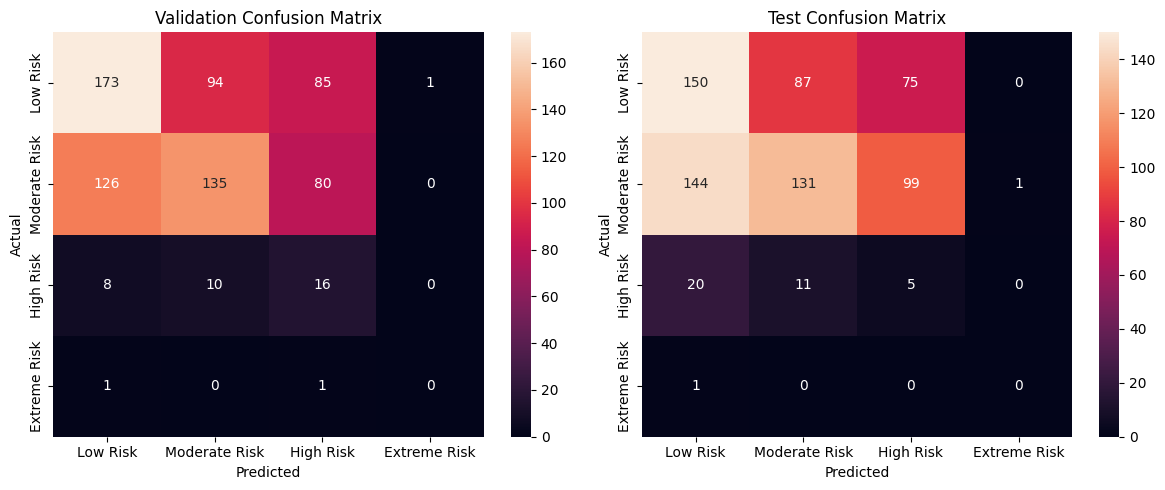

In [53]:
test_predictions = final_model.predict(X_test)
class_names = [at2.features.WHC_LABELS[class_id] for class_id in class_ids]

figure, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, predictions, actual, title in [
    (axes[0], validation_predictions, y_val, "Validation Confusion Matrix"),
    (axes[1], test_predictions, y_test, "Test Confusion Matrix")
]:
    matrix = confusion_matrix(actual, predictions, labels=class_ids)
    sns.heatmap(matrix, annot=True, fmt="d", xticklabels=class_names, yticklabels=class_names, ax=ax)
    ax.set(title=title, xlabel="Predicted", ylabel="Actual")

figure.tight_layout()

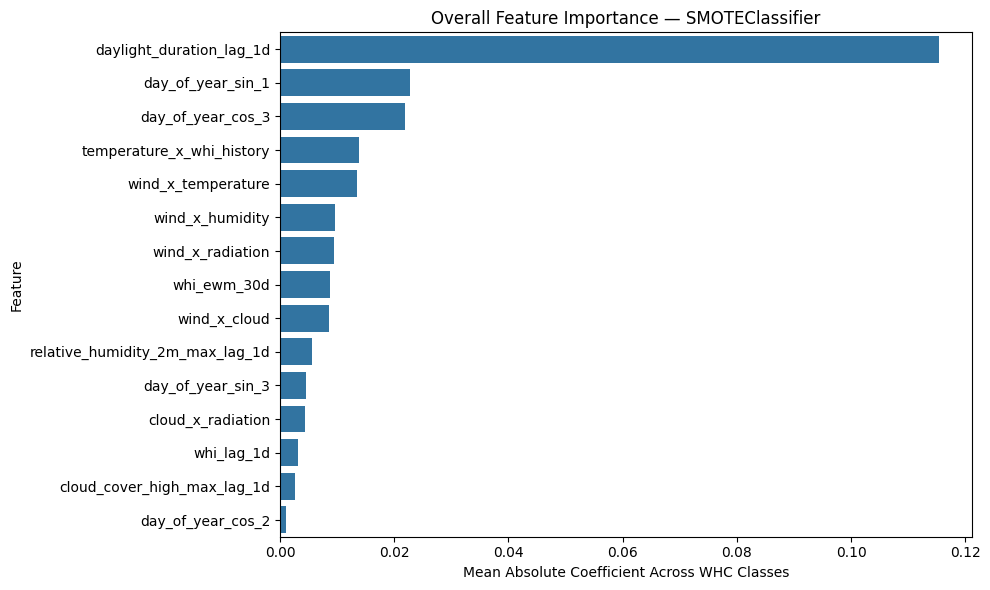

In [54]:
feature_importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": np.abs(final_model.coef_).mean(axis=0)
}).sort_values("importance", ascending=False)
plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance.head(15), x="importance", y="feature")
plt.title(f"Overall Feature Importance — {type(final_model).__name__}")
plt.xlabel("Mean Absolute Coefficient Across WHC Classes")
plt.ylabel("Feature")
plt.tight_layout()

In [55]:
prediction_distribution = pd.DataFrame({
    "actual": y_test.value_counts().sort_index(),
    "predicted": pd.Series(test_predictions, index=y_test.index).value_counts().sort_index()
}).fillna(0).astype(int)

prediction_distribution.index = [at2.features.WHC_LABELS[class_id] for class_id in prediction_distribution.index]
display(prediction_distribution)

,actual,predicted
Low Risk,312,315
Moderate Risk,375,229
High Risk,36,179
Extreme Risk,1,1


In [56]:
model_performance_explanations = f"""
The proportion-aware SMOTE model achieves a {primary_metric} of {technical_performance.loc["Training", primary_metric]:.4f} on training, {technical_performance.loc["Validation", primary_metric]:.4f} on validation and
{technical_performance.loc["Test", primary_metric]:.4f} on test. Secondary macro F1 is {technical_performance.loc["Training", secondary_metric]:.4f}, {technical_performance.loc["Validation", secondary_metric]:.4f} and
{technical_performance.loc["Test", secondary_metric]:.4f} respectively. Validation severity-weighted recall is higher than training by {technical_performance.loc["Validation", primary_metric] - technical_performance.loc["Training", primary_metric]:.4f}, 
while validation macro F1 remains close to the training value. This indicates that the additional sensitivity towards the higher-risk classes is retained on unseen validation observations without a corresponding large deterioration 
in the overall precision-recall balance. The confusion matrices show that the model now predicts across Low, Moderate and High Risk rather than concentrating mainly on the majority classes. High Risk observations are detected more 
frequently, but the increased sensitivity also produces greater overlap between High Risk and the lower-risk classes. Extreme Risk remains particularly difficult to distinguish because very few observations are available for this 
class. Overall, the results show a clear trade-off, SMOTE increases representation of the hazardous classes sufficiently for the classifier to identify more severe-risk observations, while macro F1 indicates that the selected 
configuration avoids the much larger deterioration in overall classification balance observed with more aggressive oversampling.
"""

In [57]:
# Do not modify this code
print_tile(size="h3", key="model_performance_explanations", value=model_performance_explanations)

### J.5 Business Impact from Current Model Performance

In [58]:
high_group_ids = class_ids[2:]
business_rows = []

for partition, y, predictions in [
    ("Validation", y_val, validation_predictions),
    ("Test", y_test, test_predictions)
]:
    actual_high_risk = np.isin(y, high_group_ids)
    predicted_high_risk = np.isin(predictions, high_group_ids)

    caught_high_risk = (actual_high_risk & predicted_high_risk).sum()
    missed_high_risk = (actual_high_risk & ~predicted_high_risk).sum()
    false_alerts = (~actual_high_risk & predicted_high_risk).sum()

    business_rows.append({
        "partition": partition,
        "actual_high_risk_events": actual_high_risk.sum(),
        "predicted_high_risk_alerts": predicted_high_risk.sum(),
        "caught_high_risk_events": caught_high_risk,
        "missed_high_risk_events": missed_high_risk,
        "false_high_risk_alerts": false_alerts,
        "high_risk_recall": caught_high_risk / actual_high_risk.sum(),
        "high_risk_alert_precision": caught_high_risk / predicted_high_risk.sum() if predicted_high_risk.sum() else np.nan
    })

business_impact = pd.DataFrame(business_rows).set_index("partition")
display(business_impact.round(4))

,actual_high_risk_events,predicted_high_risk_alerts,caught_high_risk_events,missed_high_risk_events,false_high_risk_alerts,high_risk_recall,high_risk_alert_precision
partition,,,,,,,
Validation,36,183,17,19,166,0.4722,0.0929
Test,37,180,5,32,175,0.1351,0.0278


In [59]:
business_impacts_explanations = f"""
On validation data, the model identifies {int(business_impact.loc["Validation", "caught_high_risk_events"])} of {int(business_impact.loc["Validation", "actual_high_risk_events"])} actual High or Extreme Risk events, giving a
high-risk recall of {business_impact.loc["Validation", "high_risk_recall"]:.2%}. On the held-out test set, it identifies {int(business_impact.loc["Test", "caught_high_risk_events"])} of {int(business_impact.loc["Test", "actual_high_risk_events"])}
hazardous events, corresponding to a recall of {business_impact.loc["Test", "high_risk_recall"]:.2%}. Although macro F1 remains relatively close to the baseline, the business-specific High/Extreme alert precision is much lower.
{business_impact.loc["Validation", "high_risk_alert_precision"]:.2%} on validation and {business_impact.loc["Test", "high_risk_alert_precision"]:.2%} on test. This is because macro F1 summarises the precision-recall balance separately 
across all four WHC classes, whereas high-risk alert precision specifically measures how many observations predicted as High or Extreme Risk are truly hazardous. The results therefore show that the selected SMOTE configuration 
preserves the broader multiclass F1 balance reasonably well while increasing sensitivity to hazardous events, but the hazardous-risk predictions themselves still contain a substantial number of false alerts.
"""

In [60]:
# Do not modify this code
print_tile(size="h3", key="business_impacts_explanations", value=business_impacts_explanations)

### J.6 Decision Boundary Analysis

In [61]:
feature_names = X_train.columns
coefficient_df = pd.DataFrame(final_model.coef_, columns=feature_names, index=final_model.classes_)
boundary_feature_rows = []
for class_1, class_2 in combinations(class_ids, 2):
    coefficient_difference = (coefficient_df.loc[class_1] - coefficient_df.loc[class_2]).abs().sort_values(ascending=False)
    top_features = coefficient_difference.head(4)
    boundary_feature_rows.append({
        "boundary": f"{at2.features.WHC_LABELS[class_1]} ↔ {at2.features.WHC_LABELS[class_2]}",
        "top_boundary_features": " | ".join(top_features.index),
        "largest_coefficient_difference": top_features.iloc[0]
    })
boundary_feature_summary = pd.DataFrame(boundary_feature_rows)
display(boundary_feature_summary.round({"largest_coefficient_difference": 4}))

,boundary,top_boundary_features,largest_coefficient_difference
0,Low Risk ↔ Moderate Risk,daylight_duration_lag_1d | day_of_year_sin_1 | day_of_year_cos_3 | relative_humidity_2m_max_lag_1d,0.4613
1,Low Risk ↔ High Risk,daylight_duration_lag_1d | day_of_year_cos_3 | temperature_x_whi_history | wind_x_temperature,0.1852
2,Low Risk ↔ Extreme Risk,daylight_duration_lag_1d | day_of_year_cos_3 | wind_x_cloud | day_of_year_sin_3,0.1852
3,Moderate Risk ↔ High Risk,daylight_duration_lag_1d | day_of_year_sin_1 | temperature_x_whi_history | wind_x_temperature,0.2762
4,Moderate Risk ↔ Extreme Risk,daylight_duration_lag_1d | day_of_year_sin_1 | whi_lag_1d | relative_humidity_2m_max_lag_1d,0.2762
5,High Risk ↔ Extreme Risk,temperature_x_whi_history | wind_x_temperature | wind_x_radiation | whi_ewm_30d,0.0552


In [62]:
test_confusion = confusion_matrix(y_test, test_predictions, labels=class_ids)
boundary_error_rows = []
for class_1, class_2 in combinations(class_ids, 2):
    index_1 = list(class_ids).index(class_1)
    index_2 = list(class_ids).index(class_2)
    class_1_to_2 = test_confusion[index_1, index_2]
    class_2_to_1 = test_confusion[index_2, index_1]
    boundary_error_rows.append({
        "boundary": f"{at2.features.WHC_LABELS[class_1]} ↔ {at2.features.WHC_LABELS[class_2]}",
        "direction_1": f"{at2.features.WHC_LABELS[class_1]} → {at2.features.WHC_LABELS[class_2]}",
        "errors_1": class_1_to_2,
        "direction_2": f"{at2.features.WHC_LABELS[class_2]} → {at2.features.WHC_LABELS[class_1]}",
        "errors_2": class_2_to_1,
        "total_cross_boundary_errors": class_1_to_2 + class_2_to_1
    })
boundary_error_df = pd.DataFrame(boundary_error_rows).sort_values("total_cross_boundary_errors", ascending=False).reset_index(drop=True)
display(boundary_error_df)

,boundary,direction_1,errors_1,direction_2,errors_2,total_cross_boundary_errors
0,Low Risk ↔ Moderate Risk,Low Risk → Moderate Risk,87,Moderate Risk → Low Risk,144,231
1,Moderate Risk ↔ High Risk,Moderate Risk → High Risk,99,High Risk → Moderate Risk,11,110
2,Low Risk ↔ High Risk,Low Risk → High Risk,75,High Risk → Low Risk,20,95
3,Low Risk ↔ Extreme Risk,Low Risk → Extreme Risk,0,Extreme Risk → Low Risk,1,1
4,Moderate Risk ↔ Extreme Risk,Moderate Risk → Extreme Risk,1,Extreme Risk → Moderate Risk,0,1
5,High Risk ↔ Extreme Risk,High Risk → Extreme Risk,0,Extreme Risk → High Risk,0,0


In [63]:
test_probabilities = final_model.predict_proba(X_test)
sorted_probabilities = np.sort(test_probabilities, axis=1)
boundary_diagnostics = pd.DataFrame({
    "actual": np.asarray(y_test),
    "predicted": np.asarray(test_predictions),
    "top_probability": sorted_probabilities[:, -1],
    "probability_margin": sorted_probabilities[:, -1] - sorted_probabilities[:, -2]
})
boundary_diagnostics = boundary_diagnostics.loc[boundary_diagnostics["actual"] != boundary_diagnostics["predicted"]].copy()
boundary_diagnostics["boundary"] = [
    f"{at2.features.WHC_LABELS[min(actual, predicted)]} ↔ {at2.features.WHC_LABELS[max(actual, predicted)]}"
    for actual, predicted in zip(boundary_diagnostics["actual"], boundary_diagnostics["predicted"])
]
boundary_confidence = (
    boundary_diagnostics
    .groupby("boundary")
    .agg(
        errors=("boundary", "size"),
        median_wrong_probability=("top_probability", "median"),
        median_probability_margin=("probability_margin", "median")
    )
    .sort_values("errors", ascending=False)
)
display(boundary_confidence.round(4))

,errors,median_wrong_probability,median_probability_margin
boundary,,,
Low Risk ↔ Moderate Risk,231,0.3148,0.0501
Moderate Risk ↔ High Risk,110,0.3201,0.0467
Low Risk ↔ High Risk,95,0.3081,0.0401
Low Risk ↔ Extreme Risk,1,0.3251,0.0576
Moderate Risk ↔ Extreme Risk,1,0.2589,0.0009


In [64]:
decision_boundary_summary = (
    boundary_error_df[["boundary", "total_cross_boundary_errors"]]
    .merge(boundary_confidence, on="boundary", how="left")
    .merge(boundary_feature_summary, on="boundary", how="left")
    .sort_values("total_cross_boundary_errors", ascending=False)
)
display(decision_boundary_summary.round(4))

,boundary,total_cross_boundary_errors,errors,median_wrong_probability,median_probability_margin,top_boundary_features,largest_coefficient_difference
0,Low Risk ↔ Moderate Risk,231,231.0,0.3148,0.0501,daylight_duration_lag_1d | day_of_year_sin_1 | day_of_year_cos_3 | relative_humidity_2m_max_lag_1d,0.4613
1,Moderate Risk ↔ High Risk,110,110.0,0.3201,0.0467,daylight_duration_lag_1d | day_of_year_sin_1 | temperature_x_whi_history | wind_x_temperature,0.2762
2,Low Risk ↔ High Risk,95,95.0,0.3081,0.0401,daylight_duration_lag_1d | day_of_year_cos_3 | temperature_x_whi_history | wind_x_temperature,0.1852
3,Low Risk ↔ Extreme Risk,1,1.0,0.3251,0.0576,daylight_duration_lag_1d | day_of_year_cos_3 | wind_x_cloud | day_of_year_sin_3,0.1852
4,Moderate Risk ↔ Extreme Risk,1,1.0,0.2589,0.0009,daylight_duration_lag_1d | day_of_year_sin_1 | whi_lag_1d | relative_humidity_2m_max_lag_1d,0.2762
5,High Risk ↔ Extreme Risk,0,NaN,NaN,NaN,temperature_x_whi_history | wind_x_temperature | wind_x_radiation | whi_ewm_30d,0.0552


In [65]:
largest_boundary = boundary_error_df.iloc[0]
high_risk_boundaries = boundary_error_df[boundary_error_df["boundary"].isin(["Low Risk ↔ High Risk", "Moderate Risk ↔ High Risk"])].sort_values("total_cross_boundary_errors", ascending=False).reset_index(drop=True)
primary_high_boundary = high_risk_boundaries.iloc[0]
secondary_high_boundary = high_risk_boundaries.iloc[1]
largest_confidence = boundary_confidence.loc[largest_boundary["boundary"]]
primary_high_confidence = boundary_confidence.loc[primary_high_boundary["boundary"]]
secondary_high_confidence = boundary_confidence.loc[secondary_high_boundary["boundary"]]
largest_features = boundary_feature_summary.loc[boundary_feature_summary["boundary"] == largest_boundary["boundary"], "top_boundary_features"].iloc[0]
primary_high_features = boundary_feature_summary.loc[boundary_feature_summary["boundary"] == primary_high_boundary["boundary"], "top_boundary_features"].iloc[0]

decision_boundary_analysis_explanations = f"""
The largest overall source of multiclass confusion is the {largest_boundary["boundary"]} boundary, with {int(largest_boundary["total_cross_boundary_errors"])} observations crossing between these classes. Its median probability
margin is only {largest_confidence["median_probability_margin"]:.4f}, indicating that many of these observations lie close to competing decision regions rather than being separated with high confidence. For the hazardous-alert 
objective, the most important errors occur at the {primary_high_boundary["boundary"]} and {secondary_high_boundary["boundary"]} boundaries, with {int(primary_high_boundary["total_cross_boundary_errors"])} and {int(secondary_high_boundary["total_cross_boundary_errors"])} 
cross-boundary errors respectively. Their median probability margins of {primary_high_confidence["median_probability_margin"]:.4f} and {secondary_high_confidence["median_probability_margin"]:.4f} show similarly weak separation 
around the High Risk region. These boundaries account for many lower-risk observations being assigned to High Risk and help explain why High/Extreme alert precision remains low. This does not contradict the comparatively stable 
macro F1. Macro F1 summarises performance across all four WHC classes, while High/Extreme alert precision focuses specifically on the reliability of hazardous-risk predictions. The model can therefore retain a reasonable overall 
multiclass precision-recall balance while still producing many false hazardous alerts. The coefficient analysis also shows that different class boundaries depend on different combinations of predictors. The {largest_boundary["boundary"]} 
separation is driven mainly by {largest_features}, while the {primary_high_boundary["boundary"]} boundary depends mainly on {primary_high_features}. Together with the small probability margins across the dominant error boundaries, 
this suggests substantial overlap and potentially conditional or threshold-dependent relationships between the WHC classes. These results motivate testing non-linear tree-based models, which can represent feature interactions and 
different threshold-dependent decision regions more flexibly than the current linear classifier.
"""

In [66]:
# Do not modify this code
print_tile(size="h3", key="decision_boundary_analysis_explanations", value=decision_boundary_analysis_explanations)

### J.7 Save Reusable Model

In [67]:
artifact_dir = at2.config.MODELS_DIR / "weather_hazard" / "experiment_2"
artifact_dir.mkdir(parents=True, exist_ok=True)
path = artifact_dir / "experiment_2.pkl"
ml_workflow.preprocessing_.clear_multiplex_data()
artifact = {
    "ml_workflow": ml_workflow,
    "model": None
}
cloudpickle.register_pickle_by_value(custom_models_module)
try:
    with path.open("wb") as file:
        cloudpickle.dump(artifact, file)
finally:
    cloudpickle.unregister_pickle_by_value(custom_models_module)
print(f"Saved Experiment 2 workflow to: {path}")

Saved Experiment 2 workflow to: /Users/ratnadeeppatra/adv_ml/36120-26SP-AT2-26294153-experiments/models/weather_hazard/experiment_2/experiment_2.pkl


## H. Project Outcomes

In [68]:
experiment_outcome = "Hypothesis Confirmed"

In [69]:
# Do not modify this code
print_tile(size="h2", key="experiment_outcomes_explanations", value=experiment_outcome)

In [70]:
test_business = business_impact.loc["Test"]
validation_business = business_impact.loc["Validation"]
largest_boundary = boundary_error_df.iloc[0]
second_boundary = boundary_error_df.iloc[1]

experiment_results_explanations = f"""
Proportion-aware SMOTE increases the classifier's sensitivity to the minority High and Extreme Risk classes and enables it to capture hazardous observations that were missed by the Experiment 1 baseline. The final model achieves 
a validation {primary_metric} of {technical_performance.loc["Validation", primary_metric]:.4f} and identifies {int(validation_business["caught_high_risk_events"])} of {int(validation_business["actual_high_risk_events"])} validation 
High/Extreme Risk events, giving a high-risk recall of {validation_business["high_risk_recall"]:.2%}. On the held-out test period, it identifies {int(test_business["caught_high_risk_events"])} of {int(test_business["actual_high_risk_events"])} 
hazardous events, corresponding to a recall of {test_business["high_risk_recall"]:.2%}. This remains an improvement in hazardous-event detection over the Experiment 1 baseline and therefore confirms the experiment hypothesis. The 
increased minority sensitivity does not come without trade-offs. Macro F1 is {technical_performance.loc["Validation", secondary_metric]:.4f} on validation and {technical_performance.loc["Test", secondary_metric]:.4f} on test, 
while High/Extreme alert precision is {validation_business["high_risk_alert_precision"]:.2%} and {test_business["high_risk_alert_precision"]:.2%} respectively. Macro F1 indicates that the broader multiclass precision-recall balance 
is reasonably preserved around the tuned validation region, but the much lower business-specific alert precision shows that hazardous predictions still contain many false alerts. The multiclass boundary analysis provides further 
evidence for this limitation. The largest sources of confusion are the {largest_boundary["boundary"]} and {second_boundary["boundary"]} boundaries, with {int(largest_boundary["total_cross_boundary_errors"])} and 
{int(second_boundary["total_cross_boundary_errors"])} cross-boundary errors respectively. The errors are therefore not explained by minority representation alone. Considerable overlap remains between the learned WHC decision regions, 
particularly around the High Risk class. Overall, Experiment 2 confirms that insufficient minority representation was one factor limiting the baseline classifier, since increasing that representation improves hazardous-event recall. 
However, the remaining false-alert burden, cross-class confusion and variation between validation and held-out performance show that SMOTE alone does not fully resolve the classification problem. The next experiment therefore retains 
the improved minority representation and tests non-linear tree-based models to determine whether more flexible threshold-dependent decision regions can provide better separation between the WHC classes.
"""

In [71]:
# Do not modify this code
print_tile(size="h2", key="experiment_results_explanations", value=experiment_results_explanations)